Main Goal of Your Project

To build a Smart Agriculture Decision Support System that recommends the most suitable crop based on soil nutrients and environmental conditions.

In simple words:

Help farmers choose the right crop for their soil and climate to improve yield and reduce risk.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/content/Crop_recommendation.csv")

In [ ]:
df.head()


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
df.describe()


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [ ]:
df.isna().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


i am adding a new column where it is called as soil moisture is done by using the if condition based the column temp, humidity, rainfall
why do we need the soil moisture:

If soil moisture is low → plants are thirsty → irrigate

If soil moisture is high → soil already wet → don’t irrigate

In [ ]:
def soil_moisture(row):
    if row['rainfall'] > 150 and row['humidity'] > 70:
        return "Wet"
    elif row['rainfall'] > 50:
        return "Moderate"
    else:
        return "Dry"

df['soil_moisture'] = df.apply(soil_moisture, axis=1)
df

,N,P,K,temperature,humidity,ph,rainfall,label,soil_moisture
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,Wet
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,Wet
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,Wet
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,Wet
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,Wet
...,...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee,Moderate
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee,Moderate
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee,Moderate
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee,Moderate


to know the soil health we use the npk and perform the health

In [ ]:
df['soil_health_index'] = (df['N'] + df['P'] + df['K']) / 3

A. Distribution of Nutrients

How N, P, K are distributed

Which nutrient is often low/high

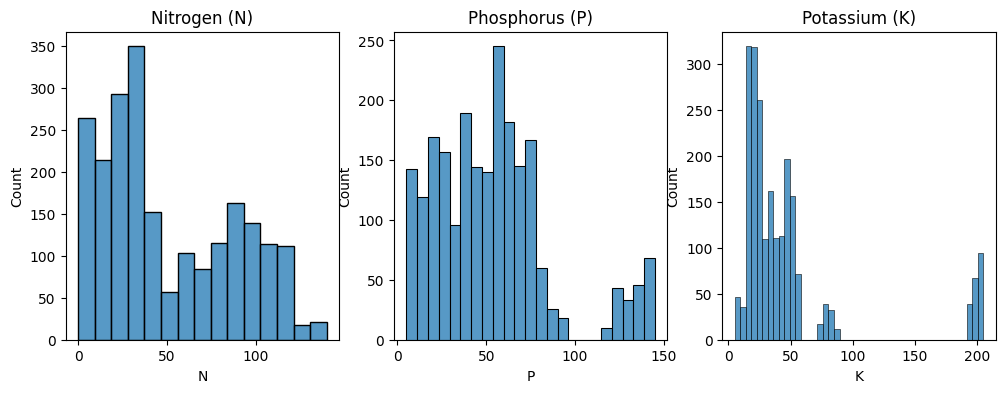

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(12,4))
sns.histplot(df['N'], ax=axes[0]); axes[0].set_title('Nitrogen (N)')
sns.histplot(df['P'], ax=axes[1]); axes[1].set_title('Phosphorus (P)')
sns.histplot(df['K'], ax=axes[2]); axes[2].set_title('Potassium (K)')
plt.show()

B. Climate vs Crop Type

Temperature vs humidity colored by crop (label)

/tmp/ipython-input-1344831326.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Crop', bbox_to_anchor=(1.05, 1), loc='upper left')


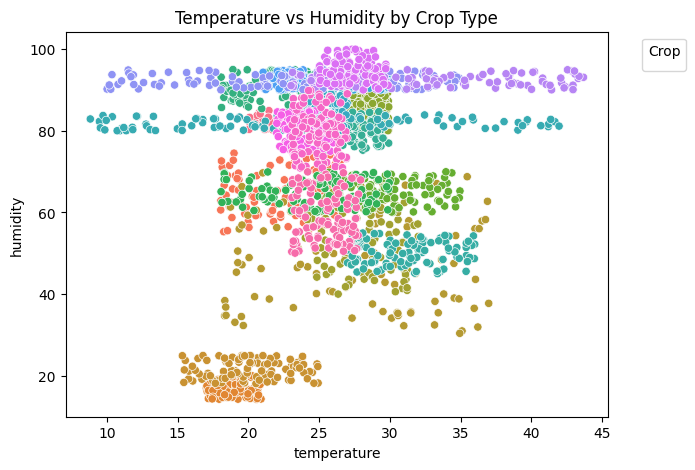

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='temperature', y='humidity', hue='label', legend=False)
plt.title("Temperature vs Humidity by Crop Type")
plt.legend(title='Crop', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

C. pH Range for Crops

Which crops prefer acidic/neutral/alkaline soil

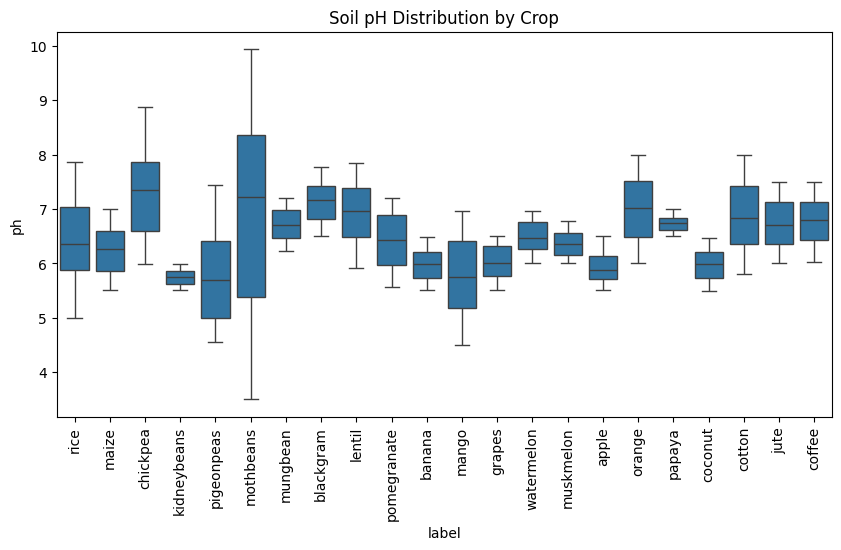

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x='label', y='ph', data=df)
plt.xticks(rotation=90)
plt.title("Soil pH Distribution by Crop")
plt.show()

rainfall vs crop

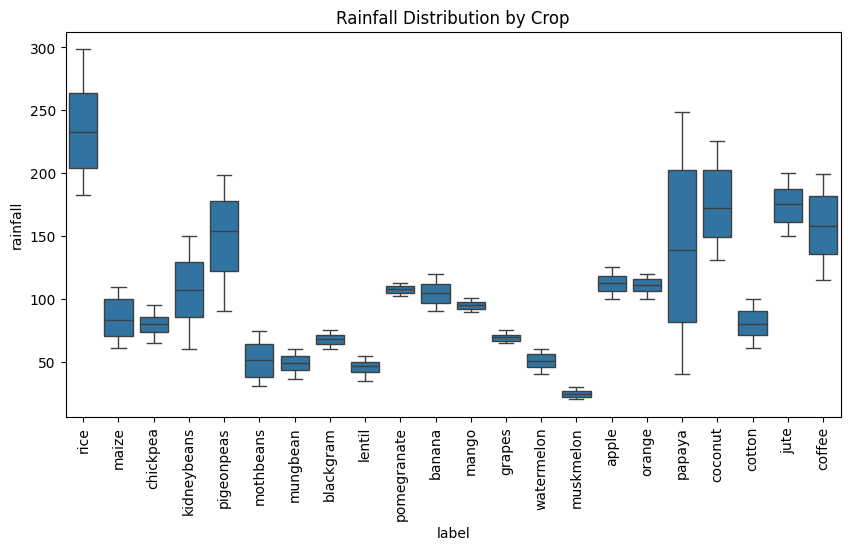

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x='label', y='rainfall', data=df)
plt.xticks(rotation=90)
plt.title("Rainfall Distribution by Crop")
plt.show()

soil health by crop

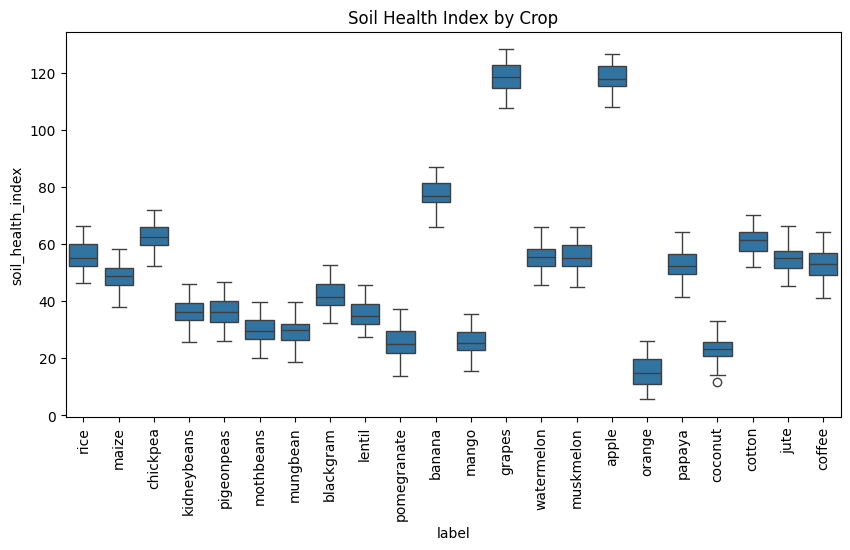

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x='label', y='soil_health_index', data=df)
plt.xticks(rotation=90)
plt.title("Soil Health Index by Crop")
plt.show()

Which Crops Grow in Which Soil Wetness

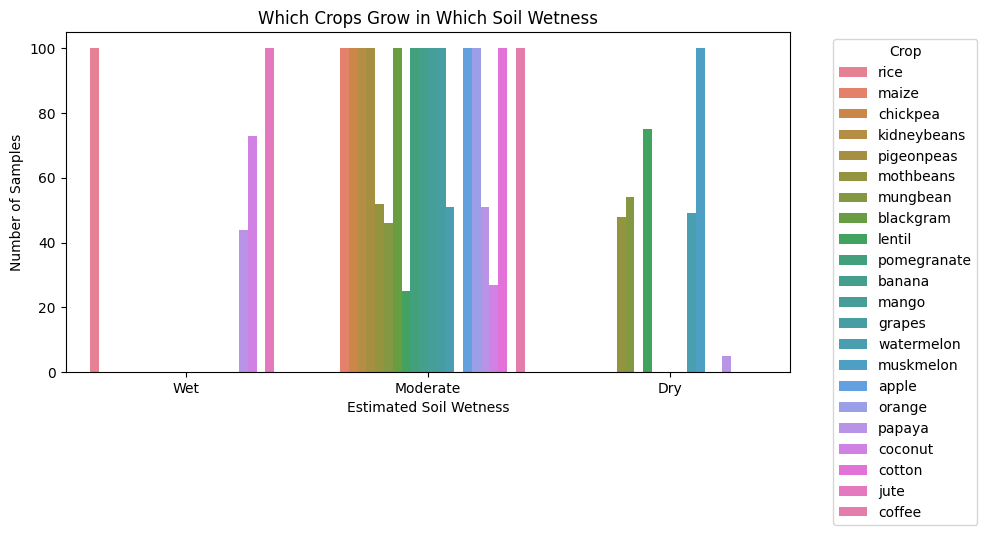

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='soil_moisture', hue='label')
plt.title("Which Crops Grow in Which Soil Wetness")
plt.xlabel("Estimated Soil Wetness")
plt.ylabel("Number of Samples")
plt.legend(title='Crop', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()